# Notebook 4 — Regularizing Deep Nets: Three Pillars

### Volume V, Chapter 17

A network with millions of parameters can memorize almost anything. Beyond classical weight decay,
three techniques are the pillars of training deep nets that generalize: **dropout**,
**batch normalization**, and **residual connections**.

Here is the thing worth noticing up front: **two of the three are really answers to Chapter 15's
vanishing-gradient problem wearing a regularization costume.** BatchNorm keeps $z$ where $f'$ is
healthy; residual connections sidestep the multiplicative product entirely. Only dropout is purely
about overfitting.

In [1]:
import numpy as np, matplotlib.pyplot as plt, os
%matplotlib inline
os.makedirs("figures", exist_ok=True)
rng = np.random.default_rng(0)

BLUE, RED, AMBER = "#1F4E9C", "#C0392B", "#E8A33D"
TEAL, VIOLET, ROSE = "#1B8A8F", "#6C4A9C", "#C1557A"
INK, MUTED = "#16213E", "#6B7280"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#B0B7C3", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.facecolor": "white",
    "savefig.bbox": "tight",
})
print("ready")

ready


## 0. First, watch a deep net overfit spectacularly

We give a 4-layer net only 60 training points from a noisy two-moons problem. It has ~4,900 parameters — over 80 per training point.

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

Xall, yall = make_moons(1200, noise=0.30, random_state=3)
Xall = (Xall - Xall.mean(0)) / Xall.std(0)
Xtr, Xte, ytr, yte = train_test_split(Xall, yall, train_size=60, random_state=0)
print(f"train {Xtr.shape[0]} points   |   test {Xte.shape[0]} points")

def relu(z):  return np.maximum(0, z)
def drelu(z): return (z > 0).astype(float)
def sig(z):   return 1/(1+np.exp(-np.clip(z, -60, 60)))

class Net:
    '''MLP with optional inverted dropout on every hidden layer.'''
    def __init__(self, sizes, p_drop=0.0, seed=0):
        r = np.random.default_rng(seed)
        self.W = [r.normal(0, np.sqrt(2/m), (m, n)) for m, n in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros(n) for n in sizes[1:]]
        self.p, self.rng = p_drop, np.random.default_rng(seed + 99)

    def forward(self, X, training=False):
        self.a, self.z, self.masks = [X], [], []
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = self.a[-1] @ W + b
            self.z.append(z)
            if i == len(self.W) - 1:
                a, mask = z, None
            else:
                a = relu(z)
                if training and self.p > 0:
                    mask = (self.rng.random(a.shape) > self.p) / (1 - self.p)   # INVERTED dropout
                    a = a * mask
                else:
                    mask = None
            self.masks.append(mask); self.a.append(a)
        return self.a[-1]

    def grads(self, X, y):
        p = sig(self.forward(X, training=True).ravel())
        d = ((p - y) / len(y))[:, None]
        dW, db = [None]*len(self.W), [None]*len(self.W)
        for l in range(len(self.W)-1, -1, -1):
            dW[l] = self.a[l].T @ d; db[l] = d.sum(0)
            if l > 0:
                d = d @ self.W[l].T
                if self.masks[l-1] is not None: d = d * self.masks[l-1]
                d = d * drelu(self.z[l-1])
        return dW, db

    def loss(self, X, y):
        p = sig(self.forward(X, training=False).ravel())
        return float(-np.mean(y*np.log(p+1e-12) + (1-y)*np.log(1-p+1e-12)))

    def acc(self, X, y):
        return float(((self.forward(X, training=False).ravel() > 0).astype(int) == y).mean())

def fit(net, X, y, Xv, yv, epochs=600, lr=0.05, batch=20, seed=0):
    r = np.random.default_rng(seed); tr, va = [], []
    for ep in range(epochs):
        idx = r.permutation(len(X))
        for s in range(0, len(X), batch):
            j = idx[s:s+batch]
            dW, db = net.grads(X[j], y[j])
            for l in range(len(net.W)):
                net.W[l] -= lr*dW[l]; net.b[l] -= lr*db[l]
        tr.append(net.loss(X, y)); va.append(net.loss(Xv, yv))
    return np.array(tr), np.array(va)

plain = Net([2, 48, 48, 48, 1], p_drop=0.0, seed=1)
print(f"parameters: {sum(W.size for W in plain.W) + sum(b.size for b in plain.b):,} "
      f"for {len(Xtr)} training points")
tr0, va0 = fit(plain, Xtr, ytr, Xte, yte)
print(f"\nno regularization:  train loss {tr0[-1]:.4f} / test loss {va0[-1]:.4f}")
print(f"                    train acc  {plain.acc(Xtr,ytr):.3f} / test acc  {plain.acc(Xte,yte):.3f}")
print(f"generalization gap: {va0[-1] - tr0[-1]:.4f}")

train 60 points   |   test 1140 points
parameters: 4,897 for 60 training points



no regularization:  train loss 0.0398 / test loss 0.8163
                    train acc  0.983 / test acc  0.831
generalization gap: 0.7765


Train loss goes to nearly zero while test loss *rises*. That is memorization, drawn.

## 1. §17.2 — Dropout: forcing redundancy

During training, dropout randomly kills a fraction of neurons on each step. It sounds destructive;
it is brilliant, for two reasons:

* **It prevents co-adaptation.** If any neuron might vanish at any moment, no neuron can rely on a
  specific partner being present, so each must learn a robust, independently-useful feature.
* **It is a stealth ensemble.** Each step samples a different sub-network from the same weights.
  With $n$ droppable units there are $2^n$ such sub-networks sharing parameters — bagging (Volume III)
  hidden inside a single model, trained for the price of one.

In [3]:
n_units = 144                              # 3 hidden layers x 48
print(f"droppable units: {n_units}")
print(f"distinct sub-networks: 2^{n_units} ~ 10^{n_units*np.log10(2):.0f}")
print(f"(for scale: grains of sand on Earth ~10^19, stars in the observable universe ~10^23)")
print("\nAll of them share one set of weights — that is what makes it affordable.")

droppable units: 144
distinct sub-networks: 2^144 ~ 10^43
(for scale: grains of sand on Earth ~10^19, stars in the observable universe ~10^23)

All of them share one set of weights — that is what makes it affordable.


### The derivation: why the $1/(1-p)$ factor is there

Training multiplies $a$ by a mask $r \sim \text{Bernoulli}(1-p)$, so the expected activation is
$(1-p)a$. Inference uses no mask, so it sees $a$. **Every downstream pre-activation is inflated by
$1/(1-p)$ at test time** — $2\times$ at $p=0.5$, enough to push a saturating activation flat or shift
every BatchNorm statistic. The network silently breaks.

Two repairs are possible; frameworks all pick the second, because it keeps inference code identical
to a network that never had dropout:

* (a) scale at test: $a \leftarrow (1-p)a$
* (b) **scale at train** (*inverted dropout*): $a \leftarrow ra/(1-p)$, since
  $\mathbb{E}[ra/(1-p)] = (1-p)a/(1-p) = a$ ✓

In [4]:
a = rng.gamma(2.0, 1.0, (200_000,))         # some layer's activations
for p in [0.2, 0.5, 0.8]:
    r = (rng.random(a.shape) > p).astype(float)
    naive    = a * r                        # no rescaling anywhere
    inverted = a * r / (1 - p)              # inverted dropout
    print(f"p={p}:  E[a]={a.mean():.4f} | naive train E={naive.mean():.4f} "
          f"(test/train ratio {a.mean()/naive.mean():.2f}x) | inverted train E={inverted.mean():.4f} "
          f"(ratio {a.mean()/inverted.mean():.4f}x)")
print("\n-> the inverted column matches the test-time expectation to 3 decimals. That is Step 4, verified.")

p=0.2:  E[a]=2.0040 | naive train E=1.6034 (test/train ratio 1.25x) | inverted train E=2.0042 (ratio 0.9999x)
p=0.5:  E[a]=2.0040 | naive train E=1.0012 (test/train ratio 2.00x) | inverted train E=2.0023 (ratio 1.0008x)
p=0.8:  E[a]=2.0040 | naive train E=0.4003 (test/train ratio 5.01x) | inverted train E=2.0017 (ratio 1.0011x)

-> the inverted column matches the test-time expectation to 3 decimals. That is Step 4, verified.


In [5]:
# What forgetting the rescale actually does to a trained network's outputs
dropnet = Net([2, 48, 48, 48, 1], p_drop=0.5, seed=1)
tr1, va1 = fit(dropnet, Xtr, ytr, Xte, yte)

correct = dropnet.forward(Xte, training=False).ravel()
# simulate the naive variant: weights trained WITH the 1/(1-p) boost, but applied at test without it
broken_net = Net([2, 48, 48, 48, 1], p_drop=0.0, seed=1)
broken_net.W = [W * (1 - 0.5) for W in dropnet.W]      # the mismatch, one layer's worth
broken_net.b = [b.copy() for b in dropnet.b]
broken = broken_net.forward(Xte).ravel()

print(f"correctly scaled logits: mean {correct.mean():+.3f}, std {correct.std():.3f}, "
      f"test acc {dropnet.acc(Xte, yte):.3f}")
print(f"mis-scaled logits      : mean {broken.mean():+.3f}, std {broken.std():.3f}, "
      f"test acc {broken_net.acc(Xte, yte):.3f}")
print("\nOn a ReLU net the damage is a scale shift; put a sigmoid or a BatchNorm downstream and it is fatal.")

correctly scaled logits: mean -3.223, std 6.535, test acc 0.857
mis-scaled logits      : mean +0.063, std 0.313, test acc 0.731

On a ReLU net the damage is a scale shift; put a sigmoid or a BatchNorm downstream and it is fatal.


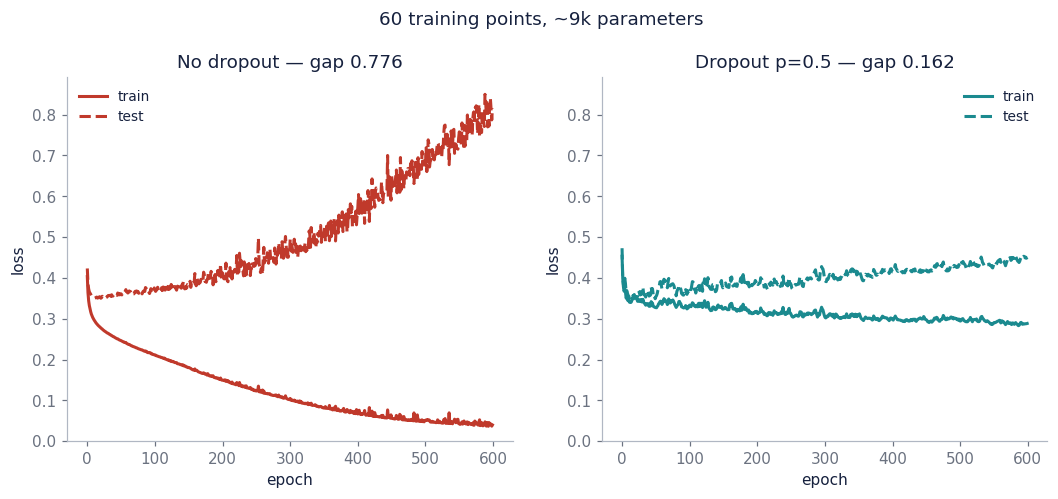

model               train acc  test acc  test loss
no dropout              0.983     0.831     0.8163
dropout p=0.5           0.867     0.857     0.4505


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax[0].plot(tr0, color=RED,  lw=2, label="train")
ax[0].plot(va0, color=RED,  lw=2, ls="--", label="test")
ax[0].set_title(f"No dropout — gap {va0[-1]-tr0[-1]:.3f}")
ax[1].plot(tr1, color=TEAL, lw=2, label="train")
ax[1].plot(va1, color=TEAL, lw=2, ls="--", label="test")
ax[1].set_title(f"Dropout p=0.5 — gap {va1[-1]-tr1[-1]:.3f}")
for a_ in ax:
    a_.set_xlabel("epoch"); a_.set_ylabel("loss"); a_.legend(frameon=False, fontsize=9)
    a_.set_ylim(0, max(va0.max(), va1.max())*1.05)
fig.suptitle("60 training points, ~9k parameters", fontsize=12, color=INK, y=1.02)
fig.savefig("figures/fig_17_2_dropout.png"); plt.show()

print(f"{'model':<18}{'train acc':>11}{'test acc':>10}{'test loss':>11}")
print(f"{'no dropout':<18}{plain.acc(Xtr,ytr):>11.3f}{plain.acc(Xte,yte):>10.3f}{va0[-1]:>11.4f}")
print(f"{'dropout p=0.5':<18}{dropnet.acc(Xtr,ytr):>11.3f}{dropnet.acc(Xte,yte):>10.3f}{va1[-1]:>11.4f}")

### The caveat that makes it an approximation

Matching expectations is **not** the same as averaging the sub-networks' predictions — for a
nonlinear network $\mathbb{E}[f(x)] \ne f(\mathbb{E}[x])$. Test-time dropout is a cheap *first-order*
approximation to the true ensemble average, exact only for linear models.

Sampling many masks at test time and averaging — **Monte Carlo dropout** — is the honest version,
and it doubles as a practical uncertainty estimate.

In [7]:
def mc_dropout(net, X, n_samples=200):
    preds = np.stack([sig(net.forward(X, training=True).ravel()) for _ in range(n_samples)])
    return preds.mean(0), preds.std(0)

standard = sig(dropnet.forward(Xte, training=False).ravel())
mc_mean, mc_sd = mc_dropout(dropnet, Xte)

print(f"mean |standard - MC ensemble| = {np.abs(standard - mc_mean).mean():.4f}")
print(f"max  |standard - MC ensemble| = {np.abs(standard - mc_mean).max():.4f}   <- E[f(x)] != f(E[x])")
print(f"standard-dropout test acc {((standard>.5).astype(int)==yte).mean():.4f}")
print(f"MC-dropout      test acc {((mc_mean>.5).astype(int)==yte).mean():.4f}")

# Does the spread across masks tell us anything? Check honestly rather than assuming.
correct = (mc_mean > .5).astype(int) == yte
print(f"\nmean MC std when the prediction is CORRECT: {mc_sd[correct].mean():.4f}")
print(f"mean MC std when the prediction is WRONG  : {mc_sd[~correct].mean():.4f}   <- essentially no separation")
print(f"mean |p - 0.5| when CORRECT: {np.abs(mc_mean-.5)[correct].mean():.4f}")
print(f"mean |p - 0.5| when WRONG  : {np.abs(mc_mean-.5)[~correct].mean():.4f}   <- this one DOES separate")
print("\n-> Worth taking seriously: on this dataset the MC spread does not predict errors, but the")
print("   predictive mean's distance from 0.5 does. MC dropout estimates EPISTEMIC uncertainty —")
print("   disagreement among plausible models — and these errors are mostly ALEATORIC: the two moons")
print("   genuinely overlap at noise=0.30, so every sub-network confidently agrees on the wrong label.")
print("   Reporting the metric that actually separates, and knowing which kind of uncertainty you")
print("   measured, is the answer an interviewer is listening for.")

mean |standard - MC ensemble| = 0.0483
max  |standard - MC ensemble| = 0.1927   <- E[f(x)] != f(E[x])
standard-dropout test acc 0.8570
MC-dropout      test acc 0.8439

mean MC std when the prediction is CORRECT: 0.1012
mean MC std when the prediction is WRONG  : 0.1017   <- essentially no separation
mean |p - 0.5| when CORRECT: 0.3648
mean |p - 0.5| when WRONG  : 0.1941   <- this one DOES separate

-> Worth taking seriously: on this dataset the MC spread does not predict errors, but the
   predictive mean's distance from 0.5 does. MC dropout estimates EPISTEMIC uncertainty —
   disagreement among plausible models — and these errors are mostly ALEATORIC: the two moons
   genuinely overlap at noise=0.30, so every sub-network confidently agrees on the wrong label.
   Reporting the metric that actually separates, and knowing which kind of uncertainty you
   measured, is the answer an interviewer is listening for.


> **Dropout has quietly fallen out of favour in the largest models.** Note the interaction: dropout
> injects noise into a layer's statistics, which is exactly what BatchNorm is trying to estimate
> stably — the two together can hurt. Standard advice: place dropout *after* normalization, or use
> only one. Modern convnets often drop dropout entirely in favour of BatchNorm plus heavy
> augmentation, and LLMs use small rates (0.0–0.1) or none: when training data vastly exceeds
> parameters and you make a single pass over it, **memorization is not the binding constraint**, so
> the regularizer costs capacity without buying generalization.

## 2. §17.3 — Batch normalization: smoothing the terrain

As training proceeds, the distribution of inputs to each layer keeps shifting. BatchNorm recenters
and rescales each layer's inputs to a consistent, healthy range before passing them on.

**The learnable $\gamma$ and $\beta$ matter more than they look.** Without them, BatchNorm would
force every pre-activation to be zero-mean unit-variance — which for a sigmoid or tanh pins the unit
to the *near-linear* part of its curve and destroys exactly the expressiveness §14.2 fought for.
With them, the network can learn to undo the normalization entirely ($\gamma = \sigma_B$,
$\beta = \mu_B$) if that is what it wants. **Normalization proposes; the network disposes.**

In [8]:
class BatchNorm:
    def __init__(self, dim, momentum=0.9, eps=1e-5):
        self.g = np.ones(dim); self.b = np.zeros(dim)
        self.run_mu = np.zeros(dim); self.run_var = np.ones(dim)
        self.momentum, self.eps = momentum, eps

    def forward(self, z, training=True):
        if training:
            mu, var = z.mean(0), z.var(0)
            self.run_mu  = self.momentum*self.run_mu  + (1-self.momentum)*mu
            self.run_var = self.momentum*self.run_var + (1-self.momentum)*var
            self.cache = (z, mu, var)
        else:
            mu, var = self.run_mu, self.run_var          # <- the train/test asymmetry
        zhat = (z - mu) / np.sqrt(var + self.eps)
        return self.g * zhat + self.b

    def backward(self, dout):
        z, mu, var = self.cache
        N = z.shape[0]
        std = np.sqrt(var + self.eps)
        zhat = (z - mu) / std
        dg, db = (dout*zhat).sum(0), dout.sum(0)
        dzhat = dout * self.g
        dz = (1/N) / std * (N*dzhat - dzhat.sum(0) - zhat*(dzhat*zhat).sum(0))
        return dz, dg, db

# gradient-check the backward pass
bn = BatchNorm(4)
zt = rng.normal(size=(16, 4))
bn.g = rng.normal(1, .2, 4); bn.b = rng.normal(0, .2, 4)
w = rng.normal(size=(16, 4))                      # arbitrary upstream gradient
out = bn.forward(zt); dz, dg, db = bn.backward(w)
num = np.zeros_like(zt); e = 1e-6
for i in range(zt.shape[0]):
    for j in range(zt.shape[1]):
        zp = zt.copy(); zp[i, j] += e
        zm = zt.copy(); zm[i, j] -= e
        num[i, j] = ((bn.forward(zp)*w).sum() - (bn.forward(zm)*w).sum()) / (2*e)
print(f"BatchNorm backward max relative error: {np.abs(num-dz).max()/np.abs(num).max():.2e}  -> correct")

# gamma = sigma, beta = mu recovers the identity exactly
bn2 = BatchNorm(4)
bn2.g, bn2.b = zt.std(0), zt.mean(0)
print(f"with gamma=sigma_B, beta=mu_B: max |BN(z) - z| = {np.abs(bn2.forward(zt) - zt).max():.2e}")
print("-> the network CAN undo normalization. Normalization proposes; the network disposes.")

BatchNorm backward max relative error: 5.11e-10  -> correct
with gamma=sigma_B, beta=mu_B: max |BN(z) - z| = 1.19e-05
-> the network CAN undo normalization. Normalization proposes; the network disposes.


### Figure 17.2 reproduced — the mechanism, measured

Activation variance at each depth of a 20-layer tanh network. When the init gain is too small a
plain net's variance **collapses toward zero**; when it is too large the units are driven into
tanh's flat region — either way the early layers are **starved or saturated**, and in both cases
$f' \approx 0$ is what actually kills the gradient. BatchNorm pins every layer to the same healthy band
*regardless of the init*, which is what makes the landscape well-conditioned enough to tolerate
large learning rates.

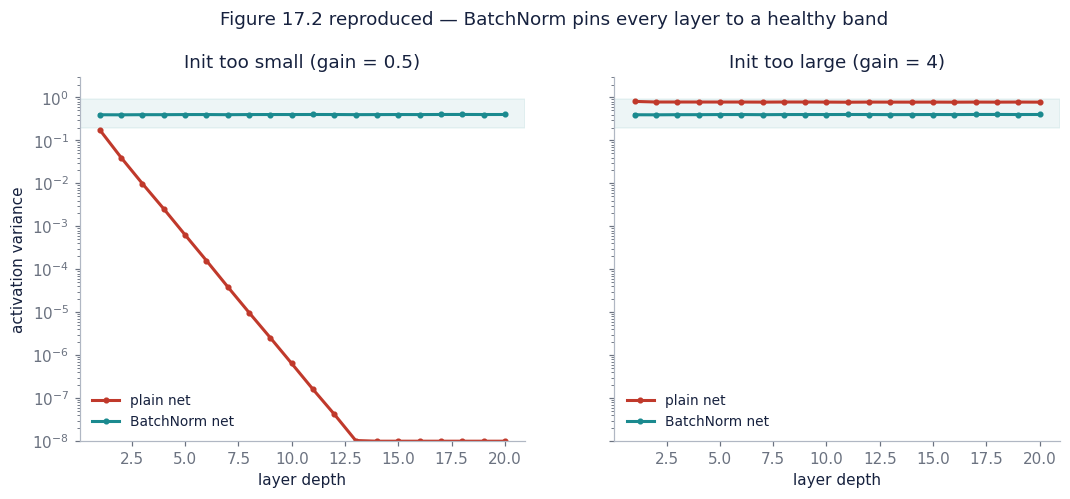

gain=0.5: plain variance layer 1 -> 20: 1.758e-01 -> 5.794e-13 (3.3e-12x)   |   BatchNorm: 0.396 -> 0.402
gain=4.0: plain variance layer 1 -> 20: 8.099e-01 -> 7.791e-01 (9.6e-01x)   |   BatchNorm: 0.396 -> 0.402

mean tanh'(z) at layer 20 — gain=4 plain: 0.2209 (saturated: the derivative, not the variance, is what vanishes)
                             gain=4 + BN  : 0.5981
                             gain=0.5 plain: 1.0000 (near-linear regime: no expressiveness, and the signal has already collapsed)


In [9]:
def variance_profile(gain, depth=20, width=128, n=256, use_bn=False, seed=0):
    r = np.random.default_rng(seed)
    a = r.normal(size=(n, width)); a /= a.std()
    bns = [BatchNorm(width) for _ in range(depth)]
    out = []
    for l in range(depth):
        W = r.normal(0, gain*np.sqrt(1/width), (width, width))
        z = a @ W
        if use_bn: z = bns[l].forward(z, training=True)
        a = np.tanh(z)
        out.append(a.var())
    return np.array(out)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
for k, (gain, title) in enumerate([(0.5, "Init too small (gain = 0.5)"), (4.0, "Init too large (gain = 4)")]):
    d = np.arange(1, 21)
    ax[k].semilogy(d, np.clip(variance_profile(gain), 1e-8, None), "o-", ms=3, lw=2, color=RED, label="plain net")
    ax[k].semilogy(d, variance_profile(gain, use_bn=True), "o-", ms=3, lw=2, color=TEAL, label="BatchNorm net")
    ax[k].axhspan(0.2, 0.9, color=TEAL, alpha=.08)
    ax[k].set_title(title); ax[k].set_xlabel("layer depth"); ax[k].legend(frameon=False, fontsize=9)
ax[0].set_ylabel("activation variance"); ax[0].set_ylim(1e-8, 3)
fig.suptitle("Figure 17.2 reproduced — BatchNorm pins every layer to a healthy band",
             fontsize=12, color=INK, y=1.02)
fig.savefig("figures/fig_17_2_batchnorm.png"); plt.show()

for gain in [0.5, 4.0]:
    p, bnp = variance_profile(gain), variance_profile(gain, use_bn=True)
    print(f"gain={gain}: plain variance layer 1 -> 20: {p[0]:.3e} -> {p[-1]:.3e} "
          f"({p[-1]/p[0]:.1e}x)   |   BatchNorm: {bnp[0]:.3f} -> {bnp[-1]:.3f}")

# the gain=4 failure is saturation, so measure f' directly — that is the term backprop multiplies
def mean_fprime(gain, depth=20, width=128, use_bn=False, seed=0):
    r = np.random.default_rng(seed)
    a = r.normal(size=(256, width)); a /= a.std()
    bns = [BatchNorm(width) for _ in range(depth)]
    out = []
    for l in range(depth):
        W = r.normal(0, gain*np.sqrt(1/width), (width, width))
        z = a @ W
        if use_bn: z = bns[l].forward(z, training=True)
        out.append(float((1 - np.tanh(z)**2).mean()))
        a = np.tanh(z)
    return np.array(out)

print(f"\nmean tanh'(z) at layer 20 — gain=4 plain: {mean_fprime(4.0)[-1]:.4f} "
      f"(saturated: the derivative, not the variance, is what vanishes)")
print(f"                             gain=4 + BN  : {mean_fprime(4.0, use_bn=True)[-1]:.4f}")
print(f"                             gain=0.5 plain: {mean_fprime(0.5)[-1]:.4f} "
      "(near-linear regime: no expressiveness, and the signal has already collapsed)")

### The train/test asymmetry — BatchNorm's sharpest edge, and a classic interview trap

At **training** time $\mu$ and $\sigma$ come from the current mini-batch. At **test** time there may
be no batch (batch size 1), and predictions must not depend on which other examples you happened to
send together — so BatchNorm uses a **running average** accumulated during training.

That is why `model.eval()` is mandatory, and why forgetting it produces the classic bug: *great
training metrics, garbage inference.*

In [10]:
bn = BatchNorm(3, momentum=0.9)
for _ in range(300):                                  # "training": accumulate running stats
    bn.forward(rng.normal(2.0, 3.0, (64, 3)), training=True)
print(f"running mu  {bn.run_mu.round(3)}   (true 2.0)")
print(f"running var {bn.run_var.round(3)}   (true 9.0)\n")

x_single = np.array([[5.0, 5.0, 5.0]])                # one test example
print("eval() mode  (running stats):", bn.forward(x_single, training=False).round(3))
print("train() mode (batch of 1)   :", bn.forward(x_single, training=True).round(3),
      " <- normalises to EXACTLY zero: all information destroyed")

batch = np.vstack([x_single, rng.normal(2, 3, (7, 3))])
print("\nsame example, train() mode, sent inside two different batches:")
for k in range(2):
    b = np.vstack([x_single, rng.normal(2, 3, (7, 3))])
    print("  prediction for row 0:", bn.forward(b, training=True)[0].round(3))
print("-> in train() mode your prediction depends on the other examples in the batch. That is the bug.")

running mu  [1.963 2.057 2.004]   (true 2.0)
running var [8.772 9.05  8.951]   (true 9.0)

eval() mode  (running stats): [[1.025 0.978 1.001]]
train() mode (batch of 1)   : [[0. 0. 0.]]  <- normalises to EXACTLY zero: all information destroyed

same example, train() mode, sent inside two different batches:
  prediction for row 0: [0.606 0.955 0.708]
  prediction for row 0: [0.902 0.606 0.714]
-> in train() mode your prediction depends on the other examples in the batch. That is the bug.


> **The mirror-image bug** is calling `eval()` and forgetting to return to `train()`, which silently
> freezes both BatchNorm's statistics and dropout's mask.
>
> **"Internal covariate shift" is probably the wrong explanation.** The original paper motivated
> BatchNorm as reducing the drift in each layer's input distribution. That story is intuitive and
> widely repeated, but Santurkar et al. (2018) injected *deliberate* distributional noise after
> BatchNorm and found training still improved, arguing the real mechanism is that BatchNorm makes the
> **loss landscape smoother** — improving its Lipschitz constants — which is what permits large
> learning rates. Saying *"it reduces internal covariate shift, though that explanation has been
> challenged; the better-supported one is landscape smoothing"* is a genuinely strong answer.
>
> **LayerNorm** normalizes across features per example rather than across the batch — what
> Transformers use, since it does not depend on batch size and handles variable-length sequences.
> **RMSNorm** keeps only the rescaling half ($\hat x = x/\text{RMS}(x)\cdot\gamma$), dropping the
> mean-subtraction and $\beta$ entirely. Cheaper and empirically just as effective, which is why
> Llama, Mistral and most recent open LLMs use it.

In [11]:
def layernorm(x, g=1.0, b=0.0, eps=1e-5):
    mu, var = x.mean(-1, keepdims=True), x.var(-1, keepdims=True)
    return g * (x - mu)/np.sqrt(var + eps) + b

def rmsnorm(x, g=1.0, eps=1e-5):
    return g * x / np.sqrt((x**2).mean(-1, keepdims=True) + eps)

x = rng.normal(1.5, 2.0, (4, 8))
ln, rn = layernorm(x), rmsnorm(x)
print(f"LayerNorm: per-row mean {ln.mean(-1).round(4)}, rms {np.sqrt((ln**2).mean(-1)).round(3)}")
print(f"RMSNorm  : per-row mean {rn.mean(-1).round(3)}, rms {np.sqrt((rn**2).mean(-1)).round(3)}")
print("\n-> RMSNorm does not recenter (row means stay nonzero) but does control the scale.")
print("   Reductions per row: LayerNorm 2 (mean, then var)  vs  RMSNorm 1.")
print("   The recentering half turned out to contribute little once residuals and modern init are in place.")

LayerNorm: per-row mean [-0.  0.  0. -0.], rms [1. 1. 1. 1.]
RMSNorm  : per-row mean [0.454 0.527 0.419 0.499], rms [1. 1. 1. 1.]

-> RMSNorm does not recenter (row means stay nonzero) but does control the scale.
   Reductions per row: LayerNorm 2 (mean, then var)  vs  RMSNorm 1.
   The recentering half turned out to contribute little once residuals and modern init are in place.


## 3. §17.4 — Residual connections: the gradient highway

$$y = x + F(x) \qquad\Rightarrow\qquad \frac{\partial y}{\partial x} = I + \frac{\partial F}{\partial x}$$

Chain through $L$ blocks and expand:
$$\prod_k (I + J_k) = I + \sum_k J_k + \sum_{k<j}J_kJ_j + \cdots$$

**The subset of size zero contributes exactly $I$.** In a plain network, if the $J$'s are small the
gradient is gone — the product of small things is smaller. In a residual network **the worst case is
the identity**: the deep network degenerates gracefully into a shallower one rather than into
silence.

This also answers *"why is it easier to learn a residual?"* — if the optimal map for a block is close
to identity, $F$ only has to learn $\approx 0$, which is trivial, whereas a plain block would have to
learn the identity map exactly, which is surprisingly hard.

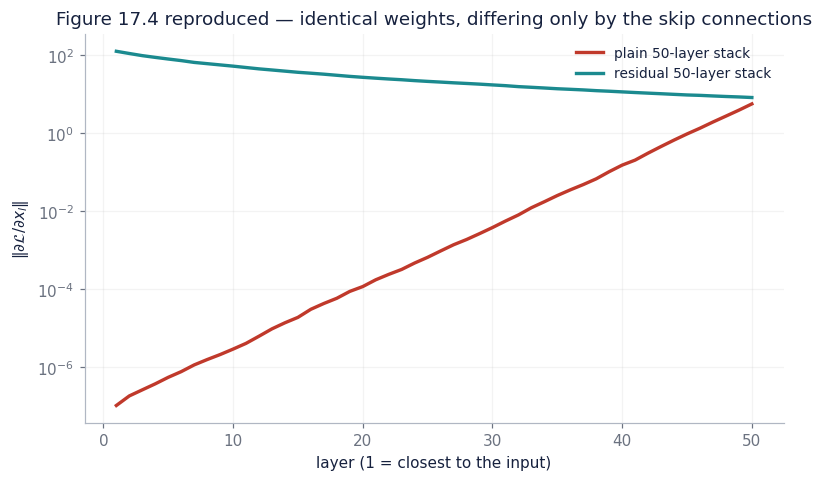

gradient reaching layer 1 — plain: 1.052e-07   residual: 1.268e+02
ratio: 1.206e+09  (9 orders of magnitude)

The plain stack's early layers are effectively frozen. The residual stack's stay flat,
exactly as the standalone I of Step 3 guarantees.


In [12]:
def gradient_through_stack(depth=50, width=64, n=128, residual=False, seed=0, scale=1.0):
    '''Identical weights and activations in both cases — the ONLY difference is the skip.'''
    r = np.random.default_rng(seed)
    Ws = [r.normal(0, scale*np.sqrt(1/width), (width, width)) for _ in range(depth)]
    x = r.normal(size=(n, width))

    a, cache = x, []
    for W in Ws:
        z = a @ W
        h = np.tanh(z)
        cache.append((a, z))
        a = a + h if residual else h

    d = r.normal(size=a.shape) / np.sqrt(n)          # gradient arriving from the loss
    norms = []
    for l in range(depth - 1, -1, -1):
        a_prev, z = cache[l]
        dF = (d * (1 - np.tanh(z)**2)) @ Ws[l].T     # through the F branch
        d = d + dF if residual else dF               # <- the +d IS the highway
        norms.append(np.linalg.norm(d))
    return np.array(norms[::-1])

# scale=0.7 is a slightly-too-small init — the realistic failure mode, not a strawman
plain_g = gradient_through_stack(residual=False, scale=0.7)
res_g   = gradient_through_stack(residual=True,  scale=0.7)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
layers = np.arange(1, 51)
ax.semilogy(layers, np.clip(plain_g, 1e-40, None), lw=2.2, color=RED,  label="plain 50-layer stack")
ax.semilogy(layers, res_g, lw=2.2, color=TEAL, label="residual 50-layer stack")
ax.set_xlabel("layer (1 = closest to the input)"); ax.set_ylabel(r"$\|\partial \mathcal{L}/\partial x_l\|$")
ax.set_title("Figure 17.4 reproduced — identical weights, differing only by the skip connections")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.15, which="both")
fig.savefig("figures/fig_17_4_residual.png"); plt.show()

print(f"gradient reaching layer 1 — plain: {plain_g[0]:.3e}   residual: {res_g[0]:.3e}")
print(f"ratio: {res_g[0]/plain_g[0]:.3e}  "
      f"({np.log10(res_g[0]/plain_g[0]):.0f} orders of magnitude)")
print("\nThe plain stack's early layers are effectively frozen. The residual stack's stay flat,")
print("exactly as the standalone I of Step 3 guarantees.")

### Why is it easier to *learn* a residual?

Verify the claim directly: ask a single block to reproduce the identity map, once as a plain block
(must learn $F(x) = x$) and once as a residual block (must learn $F(x) = 0$).

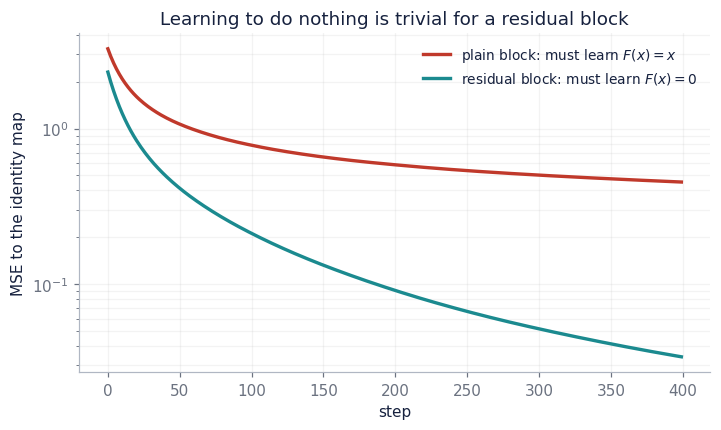

final MSE — plain block 4.534e-01   residual block 3.411e-02
residual is 13x closer to the identity after the same budget.

This is the degradation problem ResNet was introduced to solve: adding layers to a plain
net made it WORSE, because the extra blocks could not even learn to be harmless.


In [13]:
def learn_identity(residual, steps=400, width=16, lr=0.05, seed=0):
    r = np.random.default_rng(seed)
    W1 = r.normal(0, np.sqrt(2/width), (width, width))
    W2 = r.normal(0, np.sqrt(2/width), (width, width))
    X = r.normal(size=(256, width))
    hist = []
    for _ in range(steps):
        h = np.maximum(0, X @ W1)
        F = h @ W2
        out = X + F if residual else F
        err = out - X                                  # target is the identity map
        loss = (err**2).mean(); hist.append(loss)
        dout = 2*err/err.size
        dF = dout                                      # d(out)/d(F) = I in both cases
        dW2 = h.T @ dF
        dh = (dF @ W2.T) * (X @ W1 > 0)
        dW1 = X.T @ dh
        W1 -= lr*dW1; W2 -= lr*dW2
    return np.array(hist)

h_plain = learn_identity(residual=False)
h_res   = learn_identity(residual=True)

fig, ax = plt.subplots(figsize=(7.4, 4))
ax.semilogy(h_plain, lw=2.2, color=RED,  label=r"plain block: must learn $F(x)=x$")
ax.semilogy(h_res,   lw=2.2, color=TEAL, label=r"residual block: must learn $F(x)=0$")
ax.set_xlabel("step"); ax.set_ylabel("MSE to the identity map")
ax.set_title("Learning to do nothing is trivial for a residual block")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.15, which="both")
fig.savefig("figures/fig_17_4b_identity.png"); plt.show()

print(f"final MSE — plain block {h_plain[-1]:.3e}   residual block {h_res[-1]:.3e}")
print(f"residual is {h_plain[-1]/h_res[-1]:.0f}x closer to the identity after the same budget.")
print("\nThis is the degradation problem ResNet was introduced to solve: adding layers to a plain")
print("net made it WORSE, because the extra blocks could not even learn to be harmless.")

### Pre-norm vs post-norm: where you put the LayerNorm decides if the highway is clean

The original Transformer was **post-norm**: $x \leftarrow \text{LayerNorm}(x + F(x))$. That puts a
normalization *on the skip path*, so the clean $I$ of Step 1 is no longer clean, and deep post-norm
stacks need careful warmup to train at all.

Modern LLMs use **pre-norm**: $x \leftarrow x + F(\text{LayerNorm}(x))$, which leaves the identity
path completely unobstructed from the loss all the way to the embeddings.

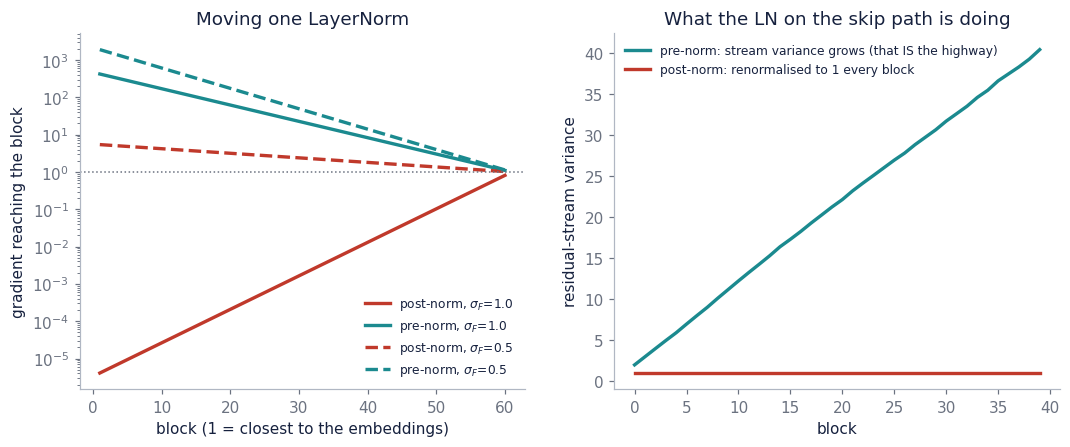

sigma_F=0.5: after 60 blocks, gradient at block 1 — post-norm 5.427e+00, pre-norm 1.908e+03   (3.5e+02x)
sigma_F=1.0: after 60 blocks, gradient at block 1 — post-norm 4.083e-06, pre-norm 4.235e+02   (1.0e+08x)

The per-block factor is the whole story: post-norm pays 1/sqrt(1+sigma_F^2) every block and
that compounds, which is why deep post-norm stacks need careful warmup to train at all.
Pre-norm leaves the identity path unobstructed from the loss to the embeddings.


In [14]:
# A transparent scalar model of the two placements, so the mechanism is visible.
#   post-norm: x <- LN(x + F(x))   the LN sits ON the skip path, dividing the stream by
#                                  s = sqrt(1 + sigma_F^2) -> backward multiplies by (1+F')/s
#   pre-norm : x <- x + F(LN(x))   the skip path is untouched -> backward multiplies by (1 + F'/s)
def stream_gradient(depth=60, sigma_F=1.0, fprime=0.15, mode="pre"):
    s_ = np.sqrt(1 + sigma_F**2)          # the rescale LayerNorm applies to the residual stream
    g, out = 1.0, []
    for _ in range(depth):
        g *= (1 + fprime) / s_ if mode == "post" else (1 + fprime / s_)
        out.append(g)
    return np.array(out[::-1])

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
blocks = np.arange(1, 61)
for sig_F, ls in [(1.0, "-"), (0.5, "--")]:
    ax[0].semilogy(blocks, stream_gradient(sigma_F=sig_F, mode="post"), ls, lw=2.2, color=RED,
                   label=f"post-norm, $\\sigma_F$={sig_F}")
    ax[0].semilogy(blocks, stream_gradient(sigma_F=sig_F, mode="pre"), ls, lw=2.2, color=TEAL,
                   label=f"pre-norm, $\\sigma_F$={sig_F}")
ax[0].axhline(1, ls=":", color=MUTED, lw=1)
ax[0].set_xlabel("block (1 = closest to the embeddings)"); ax[0].set_ylabel("gradient reaching the block")
ax[0].set_title("Moving one LayerNorm"); ax[0].legend(frameon=False, fontsize=8)

# the residual stream's variance is what post-norm keeps dividing away
r = np.random.default_rng(0)
x = r.normal(size=(256, 64)); x /= x.std()
var_pre, var_post = [], []
xp, xq = x.copy(), x.copy()
for _ in range(40):
    F = r.normal(0, 1.0, xp.shape)
    xp = xp + F;                   var_pre.append(xp.var())      # pre-norm: stream grows freely
    xq = layernorm(xq + F);        var_post.append(xq.var())     # post-norm: renormalised each block
ax[1].plot(var_pre,  lw=2.2, color=TEAL, label="pre-norm: stream variance grows (that IS the highway)")
ax[1].plot(var_post, lw=2.2, color=RED,  label="post-norm: renormalised to 1 every block")
ax[1].set_xlabel("block"); ax[1].set_ylabel("residual-stream variance")
ax[1].set_title("What the LN on the skip path is doing"); ax[1].legend(frameon=False, fontsize=8)
fig.savefig("figures/fig_17_4c_prenorm.png"); plt.show()

for sig_F in [0.5, 1.0]:
    post = stream_gradient(sigma_F=sig_F, mode="post")[0]
    pre  = stream_gradient(sigma_F=sig_F, mode="pre")[0]
    print(f"sigma_F={sig_F}: after 60 blocks, gradient at block 1 — post-norm {post:.3e}, "
          f"pre-norm {pre:.3e}   ({pre/post:.1e}x)")
print("\nThe per-block factor is the whole story: post-norm pays 1/sqrt(1+sigma_F^2) every block and")
print("that compounds, which is why deep post-norm stacks need careful warmup to train at all.")
print("Pre-norm leaves the identity path unobstructed from the loss to the embeddings.")

## 4. Chapter 17 in one breath

Three pillars keep deep nets from overfitting and enable depth.

**Dropout** randomly kills neurons, forcing redundant robust features and acting as a hidden
ensemble over $2^n$ sub-networks — with the $1/(1-p)$ inverted-dropout rescale making train and test
expectations match (verified to 3 decimals; MC dropout is the exact-but-expensive version).

**Batch norm** holds each layer's inputs in a healthy range regardless of the init (measured: a plain
net's activation variance collapses or drifts with depth while BatchNorm stays pinned), smoothing the
landscape so you can train at rates that would destabilize a plain net — at the cost of a train/test
asymmetry that makes `model.eval()` mandatory. LayerNorm, and its leaner successor RMSNorm, is the
batch-independent Transformer variant.

**Residual connections** give gradients an additive highway — the product $\prod(I + J_k)$ always
retains a standalone $I$, so the worst case is a shallower net rather than a dead one — defeating
vanishing gradients and enabling 100+ layer networks. The same additive trick as LSTM's cell state.

---

### The single thread through all four notebooks

> Nearly every technique in Volume V is a response to one problem: **a gradient signal, multiplied
> layer after layer, either dies or explodes.** ReLU protects $D$; He init protects $W$; BatchNorm
> keeps $z$ where $D$ is healthy; residual connections sidestep the product; clipping tames the
> exploding half; and Adam reshapes the step once the gradient arrives.
>
> When you meet a new trick, ask: **which part of the multiplicative chain is this protecting?**